# Assignment 5 - Timeseries

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Claude Sonnet 5|
| Used for | timeseries_dataset_from_array and sliding window |
| Verified how |gg |
| Not used for |gg |

## Imports

In [1]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from keras import layers, utils, Input, Model, callbacks, optimizers
from sklearn.preprocessing import StandardScaler
from numpy.lib.stride_tricks import sliding_window_view

utils.set_random_seed(1606009)

## Prepare inputs

In [2]:
path = kagglehub.dataset_download("mnassrib/jena-climate", output_dir="dataset")
df = pd.read_csv("dataset/jena_climate_2009_2016.csv")
print(df.shape)

(420551, 15)


The data is taken every 10 minutes from 2009 to 2016 so I will first change it to an average daily temperature to visualise the changes in `T (degC)` across time to reduce the rows from 420551.

In [3]:
# Set date time to a date dtype
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
# Isolate date column
df['Date'] = pd.to_datetime(df['Date Time']).dt.date
df['Date'] = pd.to_datetime(df["Date"], format="%Y-%M-%d")
df = df.drop(columns="Date Time")

In [4]:
# Resample to an average daily reading
df = df.groupby("Date").agg("mean").round(2)

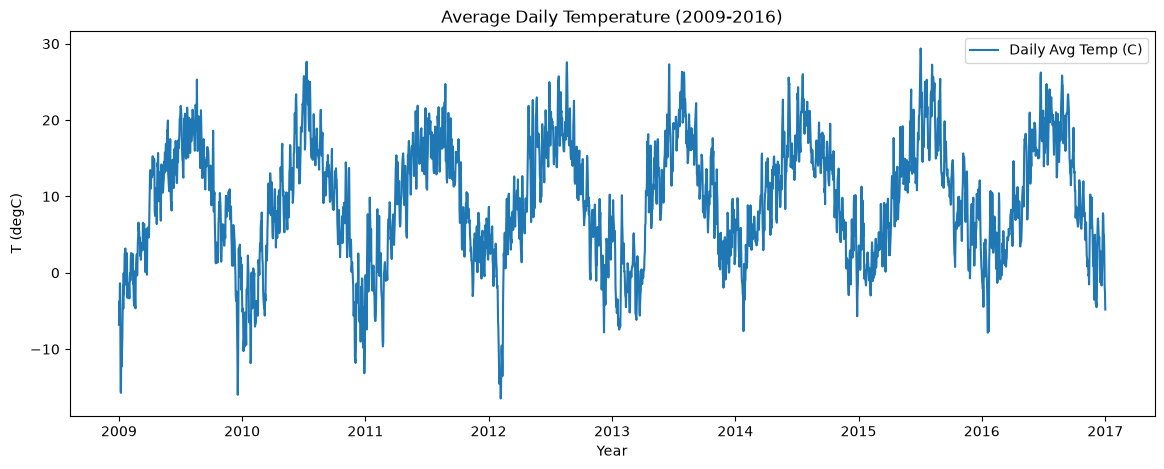

In [5]:
# Visualise daily temperatures
plt.figure(figsize=(14, 5))
plt.plot(df["T (degC)"], label="Daily Avg Temp (C)")
plt.title("Average Daily Temperature (2009-2016)")
plt.xlabel("Year")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

As the temperatures seem fairly consistent across years I will subset the data from 2013 onwards to give a full 4 years of the most recent temperature data

In [6]:
df = df.reset_index()
#df = df[df["Date"] >= "2013-01-01"]
print(df.shape)

(2921, 15)


This reduces the data to 1,460 rows, where the last 7 rows will be the test data. The validation set will be the previous 14 rows before the test set.

To decide on which parameters are useful I will run a spearman test on the correlation to `T (degC)`, and keep only significant columns for the model.

In [7]:
from scipy.stats import spearmanr

target = "T (degC)"
results = []

numeric_columns = df.select_dtypes(include="number").columns.drop(target)

for column in numeric_columns:
    pair = df[[target, column]].dropna()
    x = pair[target]
    y = pair[column]

    spearman_r, spearman_p = spearmanr(x, y)

    results.append({
        "Variable": column,
        "Spearman_rho": spearman_r,
        "Spearman_p": spearman_p
    })

test_results = pd.DataFrame(results)

# Bonferroni correction for each set of tests
n_tests = len(test_results)

test_results["Spearman_p_adjusted"] = (
    test_results["Spearman_p"] * n_tests
).clip(upper=1)

test_results["Spearman_significant"] = (
    test_results["Spearman_p_adjusted"] < 0.05
)

sig_columns = test_results[test_results["Spearman_significant"] == True]
sig_columns = list(sig_columns.Variable)
print(sig_columns)

['Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)']


In [8]:
# Add the date and temperature column then reduce dataset
sig_columns.insert(0, "Date")
sig_columns.insert(1, "T (degC)")
df = df[sig_columns]
df = df.reset_index(drop=True)

### Splitting the dataset into training, validation and test split

In [9]:
index = len(df)
test_df = df[index - 7:]
val_df = df[index - 21: index - 7]
train_df = df[:index - 21]
print("Shape of test set", test_df.shape)
print("Shape of val set", val_df.shape)
print("Shape of train set", train_df.shape)

Shape of test set (7, 11)
Shape of val set (14, 11)
Shape of train set (2900, 11)


## Normalising training set

In [10]:
TARGET = "T (degC)"
feature_cols = [c for c in df.columns if c != "Date"]
t_idx = feature_cols.index(TARGET)
n_features = len(feature_cols)

In [11]:
def scale_df(df):
    return scaler.transform(df[feature_cols])

scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

train_scaled = scale_df(train_df)
val_scaled = scale_df(val_df)
test_scaled = scale_df(test_df)

mean, std = scaler.mean_[t_idx], scaler.scale_[t_idx] # To convert back to C

### Build supervised windows

In [12]:
LOOKBACK = 28
HORIZON = 7
BATCH = 32

def make_window(split, context):
    full = np.vstack([context, split])
    data = full[:-HORIZON]
    tw = sliding_window_view(full[:, t_idx], HORIZON)
    targets = tw[LOOKBACK:]
    return utils.timeseries_dataset_from_array(
        data,
        targets=targets,
        sequence_length=LOOKBACK,
        batch_size=BATCH,
        shuffle=False
    )

empty = np.empty((0, n_features))
train_ds = make_window(train_scaled, empty)
val_ds = make_window(val_scaled, train_scaled[-LOOKBACK:])
test_ds = make_window(test_scaled, np.vstack([train_scaled, val_scaled])[-LOOKBACK:])

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    xb, yb = next(iter(ds))
    print(f"{name}: X shape - {xb.shape}, y shape - {yb.shape}")

train: X shape - (32, 28, 10), y shape - (32, 7)
val: X shape - (8, 28, 10), y shape - (8, 7)
test: X shape - (1, 28, 10), y shape - (1, 7)


## Train a sequence model

In [15]:
def get_callbacks():
    return [
        callbacks.ReduceLROnPlateau(
            monitor="val_mae",
            factor=0.5,
            patience=4
        ),
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ]

def get_baseline(ds):
    return np.concatenate([
        np.repeat(xb.numpy()[:, -1, t_idx:t_idx + 1], HORIZON, axis = 1) for xb, _ in ds
    ]) * std + mean
    
def calc_MAE(y_true, y_pred, future=False):
    if future:
        return np.abs(y_true - y_pred).mean(axis=0).round(2)
    else:
        return np.abs(y_true - y_pred).mean().round(2)

def build_model(units=32, dropout=0.2):
    inputs = Input(shape=(LOOKBACK, n_features))
    x = inputs
    x = layers.LSTM(units, dropout=dropout)(x)
    outputs = layers.Dense(HORIZON)(x)
    return Model(inputs, outputs)

def compile_model(model):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss="mse",
        metrics=["mae"]
    )
    model.summary()

def fit_model(model):
    return model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=200,
        callbacks=get_callbacks(),
        shuffle=False,
        verbose=1
    )

def evaluate_model(ds, model, name):
    y_true = np.concatenate([yb.numpy() for _, yb in ds]) * std + mean
    y_pred = model.predict(ds) * std + mean
    base = get_baseline(ds)
    print(f"{name}: model MAE = {calc_MAE(y_true, y_pred)} deg C")
    print(f"Baseline MAE = {calc_MAE(y_true, base)} deg C")
    print(f"MAE for future days ahead {calc_MAE(y_true, y_pred, future=True)}")
    return y_true, y_pred

def plot_results(y_true, y_pred):
    plt.plot(range(1, 8), y_true[0], marker="o", label="Actual")
    plt.plot(range(1, 8), y_pred[0], marker="o", label="Forecast")
    plt.xlabel("Days ahead")
    plt.ylabel("T (degC)")
    plt.legend()
    plt.show()

In [16]:
model = build_model(units=16, dropout=0.2)
compile_model(model)
history = fit_model(model)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,847 (7.21 KB)

 Trainable params: 1,847 (7.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.1319 - mae: 0.8347 - val_loss: 1.1662 - val_mae: 0.9301 - learning_rate: 1.0000e-04
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0330 - mae: 0.7974 - val_loss: 1.0289 - val_mae: 0.8856 - learning_rate: 1.0000e-04
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.9456 - mae: 0.7628 - val_loss: 0.9017 - val_mae: 0.8445 - learning_rate: 1.0000e-04
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.8606 - mae: 0.7269 - val_loss: 0.7871 - val_mae: 0.8012 - learning_rate: 1.0000e-04
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.7790 - mae: 0.6892 - val_loss: 0.6912 - val_mae: 0.7564 - learning_rate: 1.0000e-04
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.7108 - mae: 0.6563 - val_loss: 0.6162 - val_mae: 0.7128 - learning_rate: 1.0000e-04
Epoch 7/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.6413 - mae: 0.6219 - val_loss: 0.5551 - val_mae: 0.6732 - lear

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
val: model MAE = 1.98 deg C
Baseline MAE = 2.9 deg C
MAE for future days ahead [1.81 1.84 1.9  1.89 1.9  2.22 2.28]


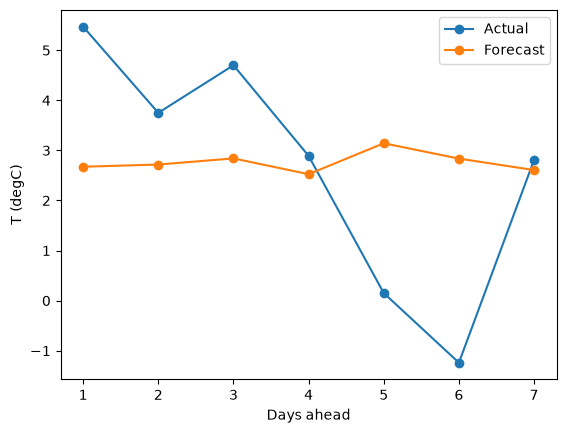

In [ ]:
y_true, y_pred = evaluate_model(val_ds, model, "val")
plot_results(y_true, y_pred)

## Report the metric

## Written responses

### Architecture summary (Moodle `a5_architecture`, max 100 words)

*Layers, sizes, and why this design fits your track.*

Originally had a dropout layer 0.2 and lstm layer with size 32 but the predictions were too flat.
can get val_mae into the 0.2's

large layers and multiple layers are worse
activations also worse: relu, tanh and sigmoid

### Input preparation (Moodle `a5_tokenisation`, max 100 words)

*Windowing / normalisation **or** tokenisation / padding / masking — whichever applies.*